In [2]:
from langgraph.graph import MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

c:\Users\Admin\Desktop\work\Agentic_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
class ChatState(MessagesState):
    summary:str

In [8]:
def chat_node(state:ChatState):
    messages= []

    if state["summary"]:
        messages.append({
            "role":"system",
            "content":f"Conversation summary: \n {state['summary']}"
        })

    messages.extend(state["messages"])
    print(messages)
          
    response = model.invoke(messages)
    return {"messages": [response]}

In [9]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [10]:
def should_summarize(state:ChatState):
    return len(state["messages"]) > 6

In [11]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [12]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

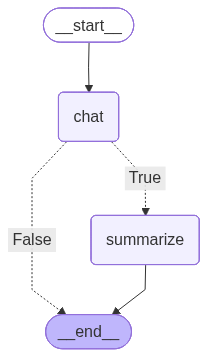

In [13]:
graph

In [14]:
config= {"configurable":{"thread_id":"t1"}}

In [15]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [17]:
out= graph.invoke({'messages':[HumanMessage(content="Quantum Physics")], 'summary': ''}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='7f4b7ad5-bbed-484f-9235-6a740ae8bcd0'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. At these scales, the classical laws of physics no longer apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quant

In [18]:
out= graph.invoke({'messages':[HumanMessage(content="How is Albert Einstine related?")], 'summary': ''}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='7f4b7ad5-bbed-484f-9235-6a740ae8bcd0'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. At these scales, the classical laws of physics no longer apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quant

In [19]:
out= graph.invoke({'messages':[HumanMessage(content="What are some of Einstien's famous work")], 'summary': ''}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='7f4b7ad5-bbed-484f-9235-6a740ae8bcd0'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. At these scales, the classical laws of physics no longer apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quant